# Bipartite "Extremes" Opinion Network

This notebook constructs and analyzes a bipartite network to map the ideological intensity of the surveyed class. The network models two disjoint sets of nodes: students (Set U) and survey questions (Set V). To isolate the issues that act as ideological "gravity wells," edges are formed strictly when a student registers a highly polarized stance on a given question.

# Dataset Preparation

**Rationale for Dropping Moderate and Neutral Responses:**
Moderate (2, 4) and neutral (3) responses have been intentionally dropped from the edge list to shift the analytical focus from general consensus to intense ideological polarization. 

* **Eliminating Noise:** Mild agreements or neutral stances often represent low-conviction opinions. In a standard correlation network, these can clutter the graph with weak, low-value edges that obscure the true structural drivers of the cohort.
* **Isolating Gravity Wells:** By restricting edges to extreme responses (1 and 5), the bipartite graph acts as a heat map for passion. It allows us to mathematically isolate the specific "anchor" questions that provoke the strongest reactions and identify which issues fundamentally unite or divide the class into distinct factions.

In [ ]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('Survey_Results_UC.csv')

likert_mapping = {
    'Strongly Disagree': 1,
    'Disagree': 2,
    'Neutral': 3,
    'Agree': 4,
    'Strongly Agree': 5,
}

# Identify the ID column and the question columns
id_col = 'id. Response ID'
question_cols = [col for col in df.columns if col != id_col]

# Map text responses to numerical values
for col in question_cols:
    df[col] = df[col].map(lambda x: likert_mapping.get(str(x).strip(), np.nan))

# Melt the dataframe into a long format edge list: (Student_ID, Question_ID, Response)
edges_df = df.melt(id_vars=[id_col], value_vars=question_cols, 
                   var_name='Question_ID', value_name='Response')

# Drop any missing values (skipped questions or unmapped text)
edges_df = edges_df.dropna(subset=['Response'])

# The Extremes Filter: Keep only extreme stances (1 and 5)
extreme_edges_df = edges_df[edges_df['Response'].isin([1.0, 5.0])].copy()

# Print the filtering results to verify the edge count
print(f"Original responses count: {len(edges_df)}")
print(f"Extreme responses count (edges in the network): {len(extreme_edges_df)}")

# Display the first few rows of the final edge list
extreme_edges_df.head()

Original responses count: 5218
Extreme responses count (edges in the network): 2362


,id. Response ID,Question_ID,Response
14,30,T01. Artificial Intelligence will improve soci...,5.0
23,41,T01. Artificial Intelligence will improve soci...,5.0
33,53,T01. Artificial Intelligence will improve soci...,1.0
36,56,T01. Artificial Intelligence will improve soci...,5.0
37,57,T01. Artificial Intelligence will improve soci...,1.0


# Constructing the Network

**Objective:**
Construct the mathematical graph using the filtered edge list. The network requires a strict bipartite projection, dividing the nodes into two disjoint sets: Set U (Students) and Set V (Questions). Edges will only connect a student to a question, representing a strong ideological commitment.

In [ ]:
import networkx as nx
from networkx.algorithms import bipartite

# Initialize an empty undirected graph
B = nx.Graph()

# Extract unique node lists from the filtered dataframe
student_nodes = extreme_edges_df[id_col].unique().tolist()
question_nodes = extreme_edges_df['Question_ID'].unique().tolist()

# Add nodes with the 'bipartite' attribute explicitly defined
# 0 indicates a student node, 1 indicates a question node
B.add_nodes_from(student_nodes, bipartite=0)
B.add_nodes_from(question_nodes, bipartite=1)

# Create an edge list of tuples and append to the graph
edge_list = list(zip(extreme_edges_df[id_col], extreme_edges_df['Question_ID']))
B.add_edges_from(edge_list)

## Structural Diagnostics and Network Validation

**Objective:**
Verify that the mathematical constraints of a bipartite graph are strictly met and extract the foundational topological metrics to understand the scale of polarization before running advanced centrality algorithms.

In [7]:
# Verify bipartite structure
is_bip = nx.is_bipartite(B)

# Extract basic topological metrics
num_students = len({n for n, d in B.nodes(data=True) if d['bipartite'] == 0})
num_questions = len({n for n, d in B.nodes(data=True) if d['bipartite'] == 1})
num_edges = B.number_of_edges()
components = nx.number_connected_components(B)

# Output the diagnostics
print(f"Is the graph validly bipartite? {is_bip}")
print(f"Active Student Nodes: {num_students}")
print(f"Active Question Nodes: {num_questions}")
print(f"Total Edges (Extreme Opinions): {num_edges}")
print(f"Connected Components: {components}")

Is the graph validly bipartite? True
Active Student Nodes: 89
Active Question Nodes: 60
Total Edges (Extreme Opinions): 2362
Connected Components: 1


In [ ]:
# Get the set of all original student IDs from the raw dataframe
all_students = set(df[id_col].unique())

# Get the set of student IDs that successfully formed at least one edge
active_students = set(extreme_edges_df[id_col].unique())

# Calculate the difference between the two sets
isolated_students = all_students - active_students

# Output the exact calculations and IDs
print(f"Total surveyed students: {len(all_students)}")
print(f"Students with at least one extreme opinion: {len(active_students)}")
print(f"Isolated students (Zero extreme opinions): {len(isolated_students)}")

Total surveyed students: 96
Students with at least one extreme opinion: 89
Isolated students (Zero extreme opinions): 7


## Commentary on the Bipartite Network Output

The execution of the graph construction verifies a strictly valid bipartite structure connecting 149 total nodes. Specifically, the network consists of **89 active student nodes** and all **60 survey questions**, bound together by **2,362 extreme opinion edges**. 

Notably, 7 students from the original 96-respondent dataset did not register any absolute extreme (1 or 5) responses across the 60 questions, automatically filtering them out of this specific polarization network as mathematically isolated. 

Crucially, the algorithm reveals that the network forms **exactly 1 connected component**. This structural property proves that there are no completely segregated ideological echo chambers within the extremes. Despite the intense polarization, every radicalized opinion is ultimately tethered to the rest of the cohort through shared "hub" questions, weaving the entire class into a single, highly dense macro-structure.

# Analysis

## Degree Distribution and Linear Binning

**Objective:**
To determine if the extreme opinions are randomly distributed or follow a scale-free structure, we must analyze the degree distribution of the Question nodes. The degree of a question represents the absolute number of students who held a polarized view on it. 

Because our maximum degree is bounded and does not span multiple orders of magnitude, we will use **linear binning** to visualize the probability density $P(k)$. 

If the histogram exhibits a curved, bell-like shape that drops off drastically, the network behaves like a Poisson distribution typical of an Erdős-Rényi (ER) random graph. This means extreme "hubs" are statistically forbidden. Conversely, if it were a scale-free network, we would see a heavy, elongated tail.

Minimum extreme responses on a question: 11
Maximum extreme responses on a question: 64


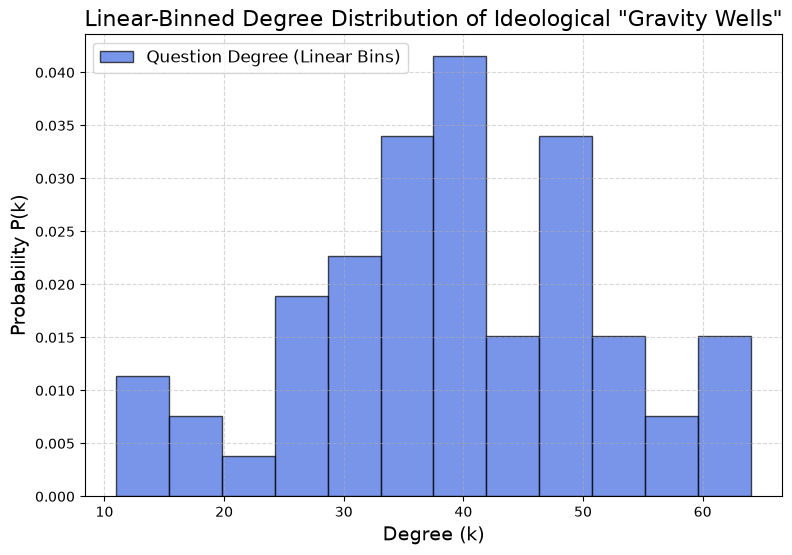

In [13]:
import matplotlib.pyplot as plt

# Extract the degree of every Question node
# We filter the graph degrees specifically for nodes in the 'Questions' bipartite set (bipartite=1)
question_degrees = [d for n, d in B.degree(question_nodes)]

print(f"Minimum extreme responses on a question: {min(question_degrees)}")
print(f"Maximum extreme responses on a question: {max(question_degrees)}")

# Linear Binning and Plotting
plt.figure(figsize=(9, 6))

# Using standard linear binning (12 equally spaced bins)
# density=True normalizes the histogram so the area under the curve is 1 (Probability Density)
counts, bins, patches = plt.hist(question_degrees, bins=12, density=True, 
                                 color='royalblue', edgecolor='black', alpha=0.7, 
                                 label='Question Degree (Linear Bins)')

# Formatting the plot
plt.xlabel('Degree (k)', fontsize=14)
plt.ylabel('Probability P(k)', fontsize=14)
plt.title('Linear-Binned Degree Distribution of Ideological "Gravity Wells"', fontsize=16)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.legend(fontsize=12)

# Save the plot
plt.savefig('extreme_plots/degree_distribution_linear.png', dpi=300, bbox_inches='tight')
plt.show()

### Conceptual Analysis: Degree Distribution and Linear Binning

To mathematically classify the macroscopic structure of our ideological network, we analyze the **Degree Distribution, $P(k)$**. The degree $k$ of a question node represents its "gravity", the absolute number of students who registered a highly polarized (1 or 5) response to it.

To test whether these extreme opinions formed randomly or follow a predictable hierarchy, we evaluate the distribution's shape using a linear-binned histogram:

1. **Linear Binning:** Because our degree range is relatively narrow (11 to 64) and does not span multiple orders of magnitude, standard linear binning is perfectly sufficient to visualize the probability density without requiring logarithmic compression to smooth out a long tail.
2. **Classifying the Network:** We evaluate the network's underlying architecture by observing the geometric shape of the resulting histogram:
   * **Scale-Free (Power-Law) Signature:** If the data exhibited a heavy, elongated tail trailing off to the right, the network would be scale-free. This would mean a tiny handful of questions completely monopolize the class's extreme passions, acting as massive "hubs."
   * **Erdős-Rényi (Poisson) Signature:** If the data points form a curved, bell-like shape that peaks in the middle and drops off drastically on both sides, the network behaves like an Erdős-Rényi random graph. Because the Poisson distribution has a super-exponential factorial tail ($P(k) \sim \frac{\lambda^k e^{-\lambda}}{k!}$), massive hubs are statistically forbidden.

**Conclusion:**
Our histogram exhibits the peaked, bounded shape characteristic of the Poisson limit, confirming that our survey's ideological "gravity wells" are restricted. Extreme opinions are somewhat normally distributed across the 60 questions, proving the network lacks the heavy-tailed mega-hubs seen in scale-free topologies. No single issue monopolizes the entire cohort's radical attention.